In [10]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.linear_model import ElasticNet
from sklearn.metrics import mean_squared_error, r2_score
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

In [11]:
from sklearn.datasets import load_diabetes

# Load the diabetes dataset as a Pandas DataFrame
diabetes = load_diabetes(as_frame=True)

# Separate features (X) and target (y)
X = diabetes.data
y = diabetes.target

# The full DataFrame including target is already provided by as_frame=True
df = diabetes.frame

# Update n_samples and n_features based on the loaded dataset
n_samples, n_features = X.shape

print("Diabetes dataset loaded successfully.")
print("Here are the first few rows of the dataset:")

Diabetes dataset loaded successfully.
Here are the first few rows of the dataset:


In [12]:
display(df.head())

,age,sex,bmi,bp,s1,s2,s3,s4,s5,s6,target
0,0.038076,0.050680,0.061696,0.021872,-0.044223,-0.034821,-0.043401,-0.002592,0.019907,-0.017646,151.0
1,-0.001882,-0.044642,-0.051474,-0.026328,-0.008449,-0.019163,0.074412,-0.039493,-0.068332,-0.092204,75.0
2,0.085299,0.050680,0.044451,-0.005670,-0.045599,-0.034194,-0.032356,-0.002592,0.002861,-0.025930,141.0
3,-0.089063,-0.044642,-0.011595,-0.036656,0.012191,0.024991,-0.036038,0.034309,0.022688,-0.009362,206.0
4,0.005383,-0.044642,-0.036385,0.021872,0.003935,0.015596,0.008142,-0.002592,-0.031988,-0.046641,135.0


In [19]:
# Use `train_test_split` to divide our features (X) and target (y).
# `test_size=0.2` means 20% of the data goes to the test set.
# `random_state=42` ensures the split is the same each time.
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"training features (X_train): {X_train.shape}")
print(f" training target (y_train): {y_train.shape}")
print(f" testing features (X_test): {X_test.shape}")
print(f" testing target (y_test): {y_test.shape}")

training features (X_train): (353, 10)
 training target (y_train): (353,)
 testing features (X_test): (89, 10)
 testing target (y_test): (89,)


##  Train an Elastic Net Regression Model



In [39]:
# Create an ElasticNet model with specific settings.
# `alpha` controls the strength of the penalty.
# `l1_ratio` controls the mix of L1 (Lasso) and L2 (Ridge) penalties.
elastic_net_model = ElasticNet(alpha=0.001, l1_ratio=0.9, random_state=42)

# Train the model using our training data.
elastic_net_model.fit(X_train, y_train)



print('coeficientd',elastic_net_model.coef_)

print('intercept',elastic_net_model.intercept_)

coeficientd [  41.46801473 -226.35657357  536.02388748  333.27992922 -206.10683985
  -32.82500911 -157.61006775  167.8957042   448.05753014   64.27751646]
intercept 151.36849515152187


In [40]:
# Use our trained model to make predictions on the test features.
y_pred = elastic_net_model.predict(X_test)

##  Evaluate the Model's Performance



In [41]:
# Calculate Mean Squared Error (MSE)
mse = mean_squared_error(y_test, y_pred)

# Calculate R-squared (R2) Score
r2 = r2_score(y_test, y_pred)

print(f"Mean Squared Error (MSE): {mse:.2f}")
print(f"R-squared (R2) Score: {r2:.2f}")

# A low MSE and high R2 (close to 1) mean our model is performing well!

Mean Squared Error (MSE): 2869.64
R-squared (R2) Score: 0.46


##  Visualize Predictions



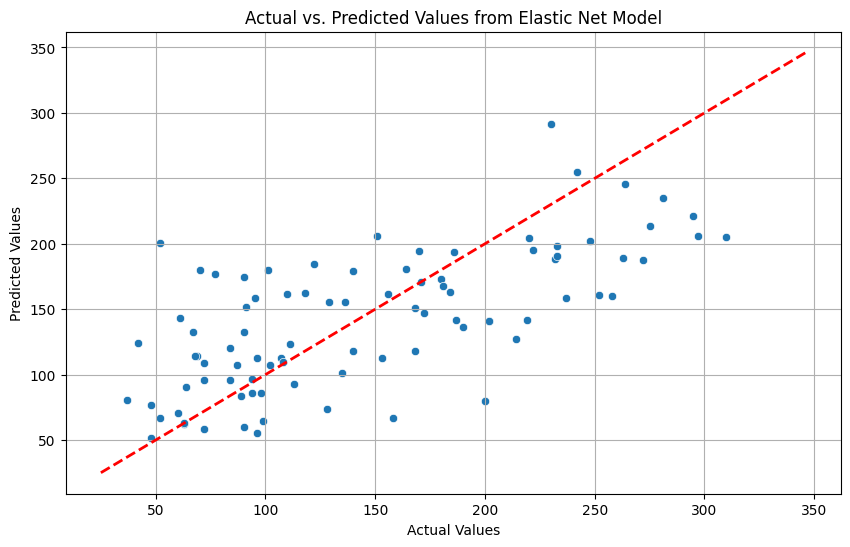

In [42]:
# Set up the plot size.
plt.figure(figsize=(10, 6))

# Create a scatter plot of actual vs. predicted values.
sns.scatterplot(x=y_test, y=y_pred)

# Draw a red dashed line that represents perfect predictions (where actual = predicted).
plt.plot([y.min(), y.max()], [y.min(), y.max()], 'r--', lw=2)

plt.xlabel("Actual Values")
plt.ylabel("Predicted Values")
plt.title("Actual vs. Predicted Values from Elastic Net Model")
plt.grid(True)
plt.show()

## Step 7: Analyze Feature Importance



Here are the feature coefficients, sorted by their absolute value (importance):


,Feature,Coefficient,Abs_Coefficient
2,bmi,536.023887,536.023887
8,s5,448.057530,448.057530
3,bp,333.279929,333.279929
1,sex,-226.356574,226.356574
4,s1,-206.106840,206.106840
7,s4,167.895704,167.895704
6,s3,-157.610068,157.610068
9,s6,64.277516,64.277516
0,age,41.468015,41.468015
5,s2,-32.825009,32.825009


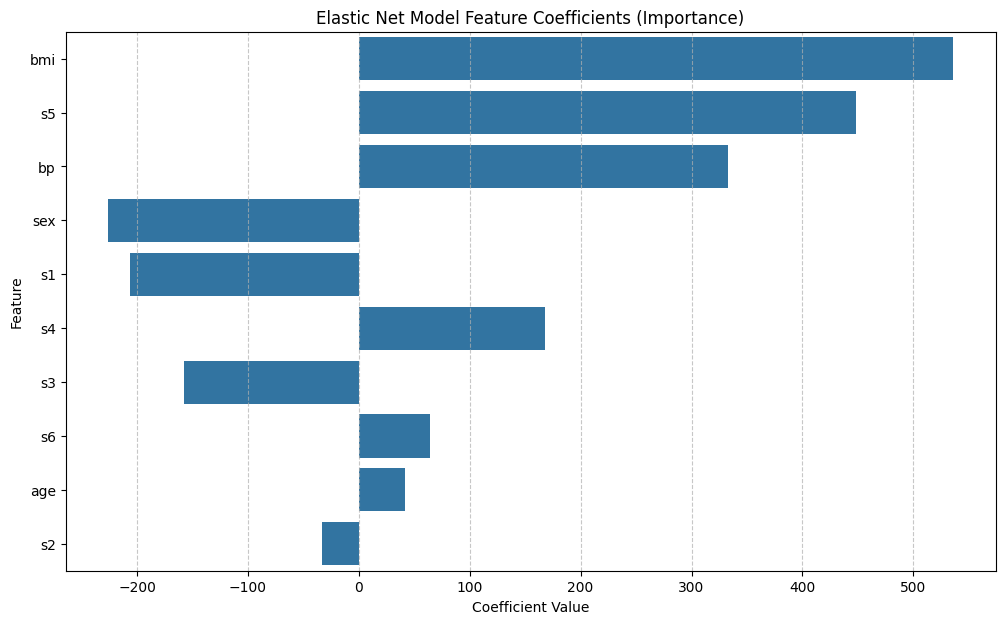

In [43]:
# Get the names of our features directly from the DataFrame columns.
feature_names = X.columns.tolist()

# Create a DataFrame to hold feature names and their learned coefficients.
coefficients_df = pd.DataFrame({'Feature': feature_names, 'Coefficient': elastic_net_model.coef_})

# Add a column for the absolute value of coefficients, useful for sorting by importance.
coefficients_df['Abs_Coefficient'] = np.abs(coefficients_df['Coefficient'])

# Sort the features by their absolute coefficient value, from most to least important.
coefficients_df = coefficients_df.sort_values(by='Abs_Coefficient', ascending=False)

print("Here are the feature coefficients, sorted by their absolute value (importance):")
display(coefficients_df)

# Create a bar plot to visualize the coefficients.
plt.figure(figsize=(12, 7))
sns.barplot(x='Coefficient', y='Feature', data=coefficients_df)
plt.title("Elastic Net Model Feature Coefficients (Importance)")
plt.xlabel("Coefficient Value")
plt.ylabel("Feature")
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.show()

## Understanding `alpha` in Elastic Net Regression

In Elastic Net regression, `alpha` (sometimes referred to as `lambda` in statistical literature) is a crucial hyperparameter that controls the **overall strength of the regularization penalty** applied to the model's coefficients.

Regularization is a technique used to prevent overfitting by adding a penalty to the loss function during model training. This penalty discourages the model from learning overly complex relationships that might only be specific to the training data.

### How `alpha` Affects Coefficients:

1.  **Strength of Regularization**: A higher `alpha` value means a stronger regularization penalty. This forces the model to shrink the magnitude of its coefficients more aggressively.

2.  **Coefficient Shrinkage**: As `alpha` increases, the coefficients of the features are pushed closer and closer to zero. This helps in reducing the impact of less important features and can simplify the model.

3.  **Model Simplicity and Bias-Variance Trade-off**: By shrinking coefficients, a higher `alpha` leads to a simpler model (higher bias, lower variance). Conversely, a lower `alpha` value allows the model to fit the training data more closely, potentially leading to more complex models (lower bias, higher variance). The goal is to find an `alpha` that balances this trade-off for optimal generalization performance.

4.  **Effect with `l1_ratio`**: While `alpha` controls the total regularization amount, `l1_ratio` determines the mix between L1 (Lasso) and L2 (Ridge) penalties. L1 regularization can lead to some coefficients becoming exactly zero (feature selection), while L2 regularization shrinks all coefficients towards zero without necessarily setting them to zero. The combined effect of `alpha` and `l1_ratio` dictates how much and in what manner coefficients are regularized.

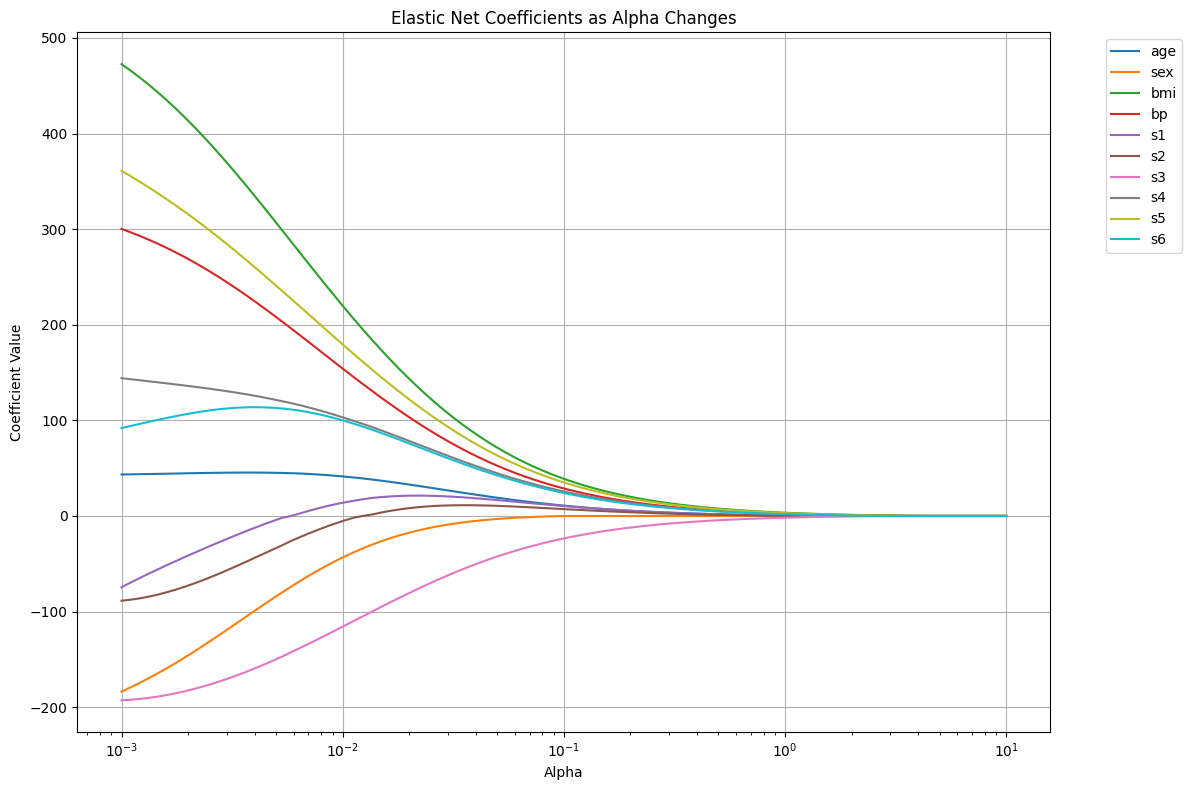

In [44]:
alpha_values = np.logspace(-3, 1, 100) # 100 values from 0.001 to 10.0
coefficients = []

for alpha in alpha_values:
    elastic_net = ElasticNet(alpha=alpha, l1_ratio=0.5, random_state=42, max_iter=10000) # Increased max_iter for convergence
    elastic_net.fit(X_train, y_train)
    coefficients.append(elastic_net.coef_)

coefficients_df_alpha = pd.DataFrame(coefficients, columns=feature_names)

plt.figure(figsize=(12, 8))
for column in coefficients_df_alpha.columns:
    plt.plot(alpha_values, coefficients_df_alpha[column], label=column)

plt.xscale('log')
plt.title('Elastic Net Coefficients as Alpha Changes')
plt.xlabel('Alpha')
plt.ylabel('Coefficient Value')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left') # Place legend outside the plot
plt.grid(True)
plt.tight_layout() # Adjust layout to prevent labels from overlapping
plt.show()



## Summary of Insights: Elastic Net Coefficients and Alpha

The visualization clearly illustrates the impact of `alpha` on the Elastic Net model's coefficients:

1.  **Coefficient Shrinkage**: As `alpha` increases (moving from left to right on the x-axis, especially in the logarithmic scale), the absolute values of the coefficients generally decrease. This demonstrates the regularization effect, where a stronger penalty pushes coefficients closer to zero.

2.  **Feature Selection (Lasso effect)**: For some features (e.g., 'sex', 's1', 's2', 's3', 's4'), their coefficients are driven to exactly zero at higher `alpha` values. This highlights the L1 regularization component (Lasso) of Elastic Net, which performs automatic feature selection by effectively removing less important features from the model.

3.  **Relative Importance**: Even with increasing `alpha`, the relative importance of features tends to remain consistent. Features that had larger absolute coefficients at lower `alpha` values (e.g., 'bmi', 'bp', 's5', 's6') generally retain relatively larger coefficients, albeit shrunk, compared to less important features.

4.  **Stability at Low Alpha**: At very small `alpha` values, the coefficients are larger and more volatile, resembling a less regularized linear regression. As `alpha` increases, the coefficients become more stable and less sensitive to small changes in the data, indicating a more robust model.

5.  **Trade-off**: The plot visually represents the bias-variance trade-off. Lower `alpha` (left side) allows for more complex models that might fit the training data very well but could overfit. Higher `alpha` (right side) leads to simpler, more generalized models, potentially with higher bias but lower variance.

In summary, by adjusting `alpha`, we can control the model's complexity and the degree of regularization, which is crucial for preventing overfitting and improving the model's generalization performance on unseen data. The plot serves as a powerful tool to understand how each feature's contribution changes under different regularization strengths.